# Cross-validation for Model_Akaike (Feb 2024)

Code by Caroline Juang, c.juang@columbia.edu

February 20, 2024

**Leave-One-Out-Cross Validation (LOOCV)**. We perform this on the same model developed in `Model_Akaike` (**Climate->Burned Area model**)

Method is as follows:
1. Iterate through three years at a time--these years will be left out of the training data
2. Train model on data without those years
3. Predict the three years left out using model
4. Create out-of-sample burned area predictions
5. Compare the Pearson correlation between log(observed BA) and log(OOS predicted BA)

Cross-validation outputs as follows, following the same csv format as the model-predicted burned area:
* `'predicted//patch125-155_nino3-34//BurnArea_crossvalid_for_patch125-155_nino3-34_1984-2022.txt'`
* `'predicted//patch125-155_nino3-34//BurnArea_crossvalid_non_patch125-155_nino3-34_1984-2022.txt'`

Resources:
* [Statology: A Quick intro to LOOCV](https://www.statology.org/leave-one-out-cross-validation/)

In [1]:
# import
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats import linregress
import joblib # for saving models
from itertools import compress
import colorcet # more colormaps

In [2]:
# suppress numpy divide by zero warning
np.seterr(divide='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## User input

In [3]:
# customize seasons for climate variables

# customize number of rolling periods
ant_years = 1 # antecedent years to include (2 antecedent years + current year)
ant_season = 3 # n+1 of months to include in each period (e.g. input 2 would mean 3 months)

firstyear = 1984
finalyear = 2022
years = np.arange(firstyear, finalyear+1)

# data directory
directory = 'your_data_directory' # customize this
# climindname is not used except for saving to a folder
# Read the climate index from the .txt file
with open('0_climindname.txt', 'r') as f:
    climindname = f.read().strip()
print(climindname +' will be used for the SST gradient')
#data_string = 'data\\'
data_string = 'data//'
model_string = 'model//'+climindname+'//'
predict_string = 'predicted//'+climindname+'//'

# folder for saving figures
figfolder = 'your_fig_folder' # customize this

patch125-155_nino3-34 will be used for the SST gradient


## Scripts

In [4]:
# average climate variables, within a selected season

def annual_seasonAvg(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: an array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth).
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time
    
    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':data[withinyear & withinseason]}).set_index('time')
    thisdf = thisdf.resample('Y').mean().reset_index()
    return thisdf.clim.values

In [5]:
# average climate variables, within a selected season

def annual_seasonSum(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: an array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth).
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time
    
    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':data[withinyear & withinseason]}).set_index('time')
    thisdf = thisdf.resample('Y').sum().reset_index()
    return thisdf.clim.values

In [6]:
# calculate AICc for variables

def getAICc(rvalue, nyears, npredictors):
    """
    Calculate the AICc, which is the Akaike Information Criterion (AIC)
    with bias correction for small sample sizes (AICc). 
    Inputs are the variables needed for the calculation. 
    Output is a single value of the AICc.
    r = r-value calculated from a Pearson Correlation
    nyears = number of years in the timeseries
    npredictors = number of x-variables used in the model
    """
    # calculate AIC
    aic = nyears * np.log(1-rvalue**2) + 2*(npredictors+1)
    # calculate AIC with bias correction for small sample size
    aicc = aic + (2*(npredictors+1)*(npredictors+2)) / (nyears - npredictors - 2)
    return aicc

In [7]:
# average climate variables, within a selected season

def annualDetrend(data):
    """
    This intakes an array of current ecoregion's climate variable of annual averages (data), 
    Output: an array of the yearly data, detrended so the slope of the data is zero.
    Requirements: 
    """

    # detrend the data
    xnum = np.arange(0,len(data))
    reg = linregress(xnum, data)
    m = reg.slope
    b = reg.intercept
    regpredict = m*xnum + b
    # normalize by subtracting the linear regression
    tmpdatanorm = (data - regpredict) + b

    return tmpdatanorm

In [8]:
# get amount in forest

def in_allregion(variable, thisregion):
    """
    For getting the average values only in this particular region of the western US.
    Requirements: the western US study area.
    Returns one weighted average of the variable for each timestep.
    """
    thisregion = westUS*thisregion # get in the study area
    weightedsum = (variable*thisregion).sum(dim=['X','Y'], skipna=True)
    regionsum = thisregion.sum()
    return  weightedsum / regionsum

def in_forest(variable, thisregion):
    """
    For getting the average values only in a forest area.
    Requirements: the forest netCDF.
    Returns one weighted average of the variable for each timestep.
    """
    forestregion = forest*thisregion # get in the region
    weightedsum = (variable*(forestregion)).sum(dim=['X','Y'], skipna=True)
    forestsum = (forestregion).sum()
    return  weightedsum / forestsum


def in_nonforest(variable, thisregion):
    """
    For getting the average values only in a nonforested area in the western US.
    Requirements: the forest netCDF, a mask of the western US.
    Returns one weighted average of the variable for each timestep and the selected region.
    """
    nonforestregion = nonforest*thisregion # get in the region
    weightedsum = (variable*(nonforestregion)).sum(dim=['X','Y'], skipna=True)
    nonforestsum = (nonforestregion).sum()
    return  weightedsum / nonforestsum

## import ecoregion data

In [9]:
# import western US study area
westUS_string = '12km//study_area//westUS.nc'
westUS = xr.open_dataset(directory + westUS_string, engine='netcdf4')
westUS = westUS.westUS

# import forest
forest_string = '12km//landcover//US_ForestType_Ruefenacht//forest_type_frac.nc'
forest = xr.open_dataset(directory + forest_string, engine='netcdf4')
forest = forest.forest_type_frac.sum(dim='ftype') # sum over all forest types

# create forest and nonforest area 
forest = westUS*forest
nonforest = westUS*(1-forest)

In [10]:
# create strings of the types of forests, remove #5
province_names = ['American Semi-Desert and Desert Province',
                  'Arizona-New Mexico Mountains Semi-Desert-Open Woodland-Coniferous Forest-Alpine Meadow Province',
                  'Black Hills Coniferous Forest Province',
                  'California Coastal Chapparral Forest and Shrub Province',
                  'California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow Province',
                  'California Coastal Steppe-Mixed Forest-Redwood Forest Province',
                  'California Dry Steppe Province',
                  'Cascade Mixed Forest-Coniferous Forest-Alpine Meadow Province',
                  'Chihuahuan Semi-Desert Province',
                  'Colorado Plateau Semi-Desert Province',
                  'Great Plains-Palouse Dry Steppe Province',
                  'Intermountain Semi-Desert Province',
                  'Intermountain Semi-Desert and Desert Province',
                  'Middle Rocky Mountain Steppe-Coniferous Forest-Alpine Meadow Province',
                  'Nevada-Utah Mountains-Semi-Desert-Coniferous Forest-Alpine Meadow Province',
                  'Northern Rocky Mountain Forest-Steppe-Coniferous Forest-Alpine Meadow Province',
                  'Pacific Lowland Mixed Forest Province',
                  'Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow Province',
                  'Southern Rocky Mountain Steppe-Open Woodland-Coniferous Forest-Alpine Meadow Province',
                  'Southwest Plateau and Plains Dry Steppe and Shrub Province']

# ecoregion info
prov_abbr_names = ['1: American Semi-Desert',
                  '2: AZ-NM Mountains',
                  '3: Black Hills Conifer Forest',
                  '4: CA Coast Chapparral Forest',
                  '5: CA Coast Range Open Woodland',
                  '6: CA Coast Steppe',
                  '7: CA Dry Steppe Province',
                  '8: Cascade Mixed Forest',
                  '9: Chihuahuan Semi-Desert',
                  '10: CO Plateau',
                  '12: Great Plains',
                  '13: IM Semi-Desert',
                  '14: IM Semi-Desert and Desert',
                  '15: Middle Rocky Mountain Steppe',
                  '16: NV-UT Mountains',
                  '17: Northern Rocky Mountain Forest',
                  '18: Pacific Lowland Mixed Forest',
                  '19: Sierran Steppe',
                  '20: Southern Rocky Mountain Steppe',
                  '21: SW Plateau and Plains']

# ecoregion names removing the ones we don't care about
# this is the label printed on everything
prov_label_names = ['1: American Semi-Desert',
                  '2: AZ-NM Mountains',
                  '3: CA Coast Chapparral Forest',
                  '4: CA Coast Range Open Woodland',
                  '5: CA Dry Steppe Province',
                  '6: Cascade Mixed Forest',
                  '7: Chihuahuan Semi-Desert',
                  '8: CO Plateau',
                  '9: Great Plains',
                  '10: IM Semi-Desert',
                  '11: IM Semi-Desert and Desert',
                  '12: Middle Rocky Mountain Steppe',
                  '13: NV-UT Mountains',
                  '14: Northern Rocky Mountain Forest',
                  '15: Sierran Steppe',
                  '16: Southern Rocky Mountain Steppe',
                  '17: SW Plateau and Plains']

province_num = [item for item in range(len(province_names)+1+1)]
province_num.remove(11) # remove empty ecoregion - no overlap btwn westUS map and ecoregion
dfnames = ['allwestUS', 'ecoprov1', 'ecoprov2', 'ecoprov3', 'ecoprov4', 'ecoprov5', 
           'ecoprov6', 'ecoprov7', 'ecoprov8', 'ecoprov9', 'ecoprov10', 
           'ecoprov12','ecoprov13','ecoprov14','ecoprov15',
           'ecoprov16','ecoprov17','ecoprov18','ecoprov19','ecoprov20','ecoprov21']

# translate years into dates
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

## Import fire, climate data
from `Data_CreateModelData`

model data from `Model_Akaike` and `Model_ENSOfull12-2022`

In [11]:
# import fire data, both modis and wumi databases
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

In [12]:
# import model data

dfframesall = {}
dfframesfor = {}
dfframesnon = {}

for iecoreg in np.arange(len(province_num)):
    filename = data_string + 'climate_ecoprovinces_'
    dfframesall[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_all.txt').set_index('Unnamed: 0')
    dfframesfor[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_for.txt').set_index('Unnamed: 0')
    dfframesnon[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_non.txt').set_index('Unnamed: 0')

# in km2, the minimum fire sum for model to be valid
minfiresum = 200

# variables with known correlation with burned area in forest 
# in current year
clim_negcorr = ['wetdays', 'prec', 'rh'] # should be negative
clim_poscorr = ['vpd', 'tmax', 'tmin', 'solar'] # should be positive
clim_poscorrboth = ['wind'] # forest and nonforest
clim_correxclude = ['rh y0', 'tmean y0',
                 'tmean y-1','rh y-1',
                 'wind y-1', 'tmax y-1','tmin y-1',
                 'wetdays y-1','solar y-1','vpd y-1'] # remove most of the prior-year variables

In [13]:
# import climate with detrended SST scenario
# this is from Model_ENSOfull12-2022 where climate under a detrended gSST
# scenario is used (observed climate minus the contribution from gSST)

dfsstclimfor = {}
dfsstclimnon = {}

for thisname in dfnames:
    filename = predict_string + 'Climate_' + thisname + '_sstpred_'
    filenameend = 'DeTrendClimObs_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
    dfsstclimfor[thisname] = pd.read_csv(filename + 'for_' + filenameend).set_index('Unnamed: 0')
    dfsstclimnon[thisname] = pd.read_csv(filename + 'non_' + filenameend).set_index('Unnamed: 0')


## Import climate data
from `Data_CreateModelData`

In [14]:
# storage for each model's variable indices
dfmodelfor = {}
dfmodelnon = {}

# storage for timeseries of BA_model 
# (all values predicted from LOOCV-ed model)
BACVpredfor = {}
BACVprednon = {}

# storage for detrended versions of timeseries of BA model
BACVsstfor = {}
BACVsstnon = {}

Akaike Information Criterion - https://doi.org/10.1109/TAC.1974.1100705

```AIC = Nyears * log(1-r.^2) + 2*(Npredictors+1)```

* `r^2` = square of the correlation coefficient
* `Nyears` = number of years in the timeseries
* `Npredictors` = the number of timeseries you're using as predictors
* rewarded for large sample size, penalized for adding more number of predictors

regression and time series model selection in small samples: https://doi.org/10.1093/biomet/76.2.297

```AICc = AIC + (2*(Npredictors+1)*(Npredictors+2))/(Nyears - Npredictors - 2)```
* bias correction on the AIC

### Leave One Out Cross Validation (LOOCV)

(2/23/2024)

1. Create a list that iterates through what to leave out
2. Iterate through Climate-Burned Area model, training on all data except the data that is left out
3. Make a prediction using the model, store the data for the years left out as a timeseries
4. A timeseries is created generated from models with only out-of-sample years.
5. Generate the r-value comparing the LOOCV-timeseries with observed timeseries of Burned Area.

In [15]:
# construct what to leave out
nleaveout = 3

numbers = list(range(len(years)))

# Divide the list into groups of 3
groupsleaveout = [numbers[i:i+3] for i in range(0, len(numbers), 3)]

# error ensemble
nensemble = 500 # number of ensemble members

In [16]:
# have a log version of WUMI (for error calculation)
# BAclimpred is already log
BA_obsfor = np.ma.masked_invalid(np.log10(wumifor)).filled(0)
BA_obsnon = np.ma.masked_invalid(np.log10(wuminon)).filled(0)
BA_obsfor = pd.DataFrame(BA_obsfor, index=years, columns=dfnames)
BA_obsnon = pd.DataFrame(BA_obsnon, index=years, columns=dfnames)

In [ ]:
# same model for FOREST area
print('FOREST')
landname = 'for'
labels = dfframesfor['ecoprov1'].columns.values # each climate variable

for iregion in np.arange(len(province_num)):
    print('+++ model for ' + dfnames[iregion] + '\t AICC \t r-value')
    # PLOT
    fig, ax = plt.subplots(dpi=50)
    ax.plot(years, wumifor.iloc[:,iregion], color='k', zorder=2)
    ax.set_title(dfnames[iregion])
    BACVtmpstorage = np.zeros(len(wumifor.iloc[:,0])) # storage
    BACVtmpstorageDT = np.zeros(len(wumifor.iloc[:,0])) # storage for dt scenario
    for leavethis in groupsleaveout:
        #print('these groups left out: {}'.format(leavethis))
        tmpr = np.zeros(len(labels)) # storage for regression correlation
        tmpr_clim = np.zeros(len(labels)) # storage for r corr, clim vs. BA
        tmpr_climDT = np.zeros(len(labels)) # storage for r corr, climDT vs. BA_DT
        aicc = np.zeros(len(labels)) # storage for aicc values for each set of reg fit
        tmpaicc = [] # storage for aicc values for each model
        tmpi = [] # empty list of indices for variables
    
        # get observed ecoregion burned area, but set min value
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wumifor.iloc[:,iregion])).filled(0))
    
        # leave one out!
        tmpfire = np.delete(tmpfire, leavethis)
        
        tmpfiremin = tmpfire[tmpfire!=0].min()
        tmpfire[tmpfire==0] = tmpfiremin # replace 0 with minimum nonzero value
        tmpfireDT = annualDetrend(tmpfire)

        tmpfiresum = wumifor.iloc[:,iregion].sum()
        
        for i, label in enumerate(labels):
            tmpclim = np.asarray(dfframesfor[dfnames[iregion]][label].values)
            # leave one out! 
            tmpclim = (np.delete(tmpclim, leavethis)).reshape(-1,1)
            tmpclimDT = annualDetrend(tmpclim.flatten())
            reg = LinearRegression() # least squares
            reg.fit(tmpclim, tmpfire)
            tmppredict = reg.predict(tmpclim)
            tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
            # calculate AICc for each
            nyears = len(tmpfire)
            npredictors = reg.n_features_in_
            aicc[i] = getAICc(tmpr[i], nyears, npredictors)
            # compare signs
            tmpr_clim = pearsonr(tmpclim.flatten(), tmpfire)
            tmpr_climDT = pearsonr(tmpclimDT, tmpfireDT)
            # check if the correlation is right sign intuitively
            tmplabeljustvar = label.split(' ')[0]
            tmplabeljustyr = label.split(' ')[1]
            tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
            # wrong signs
            tmpwrong1 = (tmpr_clim.statistic > 0) & ((tmplabeljustvar in clim_negcorr)&(tmplabeljustyr in ['y0']))
            tmpwrong2 = (tmpr_clim.statistic < 0) & ((tmplabeljustvar in clim_poscorr)&(tmplabeljustyr in ['y0']))
            tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
            tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
            if tmpwrong1 or tmpwrong2 or tmpwrong3 or tmpwrong4:
                aicc[i] = 99 # overwrite the AICc value
            # check if they are the same sign
            tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
            tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
            #if tmpsign==False:
            #    print('\tSIGN CHANGE ' + label + '\t'+
            #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
            #if tmppvalue==False:
            #    print('\tDT INSIGNIFICANT ' + label + '\t'+
            #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
            if (tmpsign==False) or (tmppvalue==False):
                aicc[i] = 99 # overwrite the AICc value
                #print('\tOverwrite AICc')
        # get minimum
        [iminaicc, minaicc] = np.argmin(aicc), np.min(aicc)
        tmpi.append(iminaicc) # add min to list of variables
        tmpaicc.append(minaicc) # add aicc value to list
        
        if (minaicc>0) or (tmpfiresum<minfiresum): # we overwrite the model and exit
            # need all write/output requirements because we're EXITING  THIS leavethis in GROUPSLEAVEOUT!!!
            tmpclim = np.asarray(dfframesfor[dfnames[iregion]].iloc[:,tmpi].values)
            # leave one out!
            tmpclim = np.delete(tmpclim, leavethis).reshape(-1,1)
            reg = LinearRegression()
            reg.fit(tmpclim, tmpfire)
            reg.coef_ = np.asarray([0]) # change coeff to 0
            reg.intercept_ = np.asarray(tmpfire.mean())
            #f_vars.write(labels[iminaicc] + '\n' + str(tmpclim.flatten()) + '\n') # write variable data to file
            #print('\tAICc POSITIVE--EXIT')
            #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
            #      str(np.round(tmpr[iminaicc], decimals=3)))
            tmpcoef = reg.coef_
            tmpintercept = reg.intercept_
 
            # re-predict with full timeseries
            tmpclim = np.asarray(dfframesfor[dfnames[iregion]][label].values).reshape(-1,1)
            tmppred = reg.predict(tmpclim)
    
            dfmodelfor[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list0.
            
            # (9/8/2024) ADD ERROR ENSEMBLE
            # create random error matrix (with replacement, index left in)
            istop = 0
            iyears = np.arange(0,len(years)) # index of each year
            errormatrix = np.empty((0,len(years)))
            while istop < (nensemble):
                # randomly select errors and construct a timeseries (years x ensembles)
                tmprandom = np.array([np.random.choice(iyears) for i in range(len(iyears))])
                tmprandom = tmprandom.reshape(1, -1)
                errormatrix = np.concatenate([errormatrix, 
                                              tmprandom], axis=0)
                istop+=1
            # error time series (BA obs - model)
            tmpBA_error_log10 = BA_obsfor.iloc[:,iregion] - tmppred
            # get nensemble of random errors
            tmpBA_randomerror = np.empty((0,len(years)))
            for j in np.arange(0,nensemble):
                tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
                tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                                   tmpcolerror], axis=0)
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred = np.log10(tmpBA_mod_plus_error1)

            # (11/17/2025) Predict climate under detrended gSST scenario
            # fits it to the model trained on observed climate
            tmpX = dfsstclimfor[dfnames[iregion]].iloc[:,tmpi] 
            tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
            # add error ensemble
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred_DT = np.log10(tmpBA_mod_plus_error1)
            
    
            # save the predicted values (only the out-of-sample ones
            BACVtmpstorage[leavethis] = tmppred[leavethis]
            BACVtmpstorageDT[leavethis] = tmppred_DT[leavethis]

            # PLOT
            ax.plot(years, 10**(tmppred), color='red', zorder=0)
            ax.plot(years, 10**(tmppred_DT), color='dodgerblue', zorder=0)
    
            # save the predicted values (only the out-of-sample ones
            BACVtmpstorage[leavethis] = tmppred[leavethis]
            
            # PLOT
            ax.plot(years, 10**(tmppred), color='red', zorder=0)
            continue # leave this loop
        
        # calculate residuals from one-variable model
        # and leave one out!
        tmpclim = dfframesfor[dfnames[iregion]].iloc[:,tmpi].drop(leavethis).values
        reg = LinearRegression()
        reg.fit(tmpclim, tmpfire)
        tmppredictprior = reg.predict(tmpclim)
    
        #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
        #          str(np.round(tmpr[iminaicc], decimals=3)))
        
        # define starting difference in aicc to get the for-loop to start
        diffaicc = -3
        # multiple regression using remaining predictor, until aicc is not improved
        while diffaicc < -2:
            # add another variable to get new model
            # calculate residuals
            tmpresids = np.log10((10**tmpfire)/(10**tmppredictprior))
            # go through each variable and get the correlation
            tmpr = np.zeros(len(labels)) # storage for regression correlation
            for i, label in enumerate(labels):
                tmpclimnew = np.asarray(dfframesfor[dfnames[iregion]][label])
                # leave one out!
                tmpclimnew = np.delete(tmpclimnew, leavethis).reshape(-1,1)
                tmpclimprior = dfframesfor[dfnames[iregion]].iloc[:,tmpi].drop(leavethis).values
                tmpX = np.hstack((tmpclimprior, tmpclimnew)) # all X variables
                tmpclimnewDT = annualDetrend(tmpclimnew.flatten())
                tmpresidsDT = annualDetrend(tmpresids)
                reg = LinearRegression() # least squares
                reg.fit(tmpX, tmpfire)
                tmppredict = reg.predict(tmpX)
                tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
                # calculate AICc for each
                nyears = len(tmpfire)
                npredictors = reg.n_features_in_
                aicc[i] = getAICc(tmpr[i], nyears, npredictors)
                # compare signs
                tmpr_clim = pearsonr(tmpclimnew.flatten(), tmpresids)
                tmpr_climDT = pearsonr(tmpclimnewDT, tmpresidsDT)
                # check if the correlation is right sign intuitively
                tmplabeljustvar = label.split(' ')[0]
                tmplabeljustyr = label.split(' ')[1]
                tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
                # wrong signs
                tmpwrong1 = (tmpr_clim.statistic > 0) & ((tmplabeljustvar in clim_negcorr)&(tmplabeljustyr in ['y0']))
                tmpwrong2 = (tmpr_clim.statistic < 0) & ((tmplabeljustvar in clim_poscorr)&(tmplabeljustyr in ['y0']))
                tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
                tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
                if tmpwrong1 or tmpwrong2 or tmpwrong3 or tmpwrong4:
                    aicc[i] = 99 # overwrite the AICc value
    
                # check if they are the same sign
                tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
                tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
                #if tmpsign==False:
                #    print('\tSIGN CHANGE ' + label + '\t'+
                #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
                #if tmppvalue==False:
                #    print('\tDT INSIGNIFICANT ' + label + '\t'+
                #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
                if (tmpsign==False) or (tmppvalue==False):
                    aicc[i] = 99 # overwrite the AICc value
                    #print('\tOverwrite AICc')
    
            # get minimum
            [iminaicc, minaicc] = np.nanargmin(aicc), np.nanmin(aicc)
            # check aicc value to previous value
            diffaicc = minaicc - tmpaicc[-1]
            # check if diff aicc is small enough before continuing
            #print('diffaicc = {:} - {:}'.format(minaicc, tmpaicc[-1]))
            if (diffaicc >= -2):
                #print('difference is too big, EXIT ' + str(diffaicc)) 
                continue # exit loop
            else:
                # continue this part if aicc < -2
                tmpi.append(iminaicc) # add min to list of variables
                tmpaicc.append(minaicc) # add aicc value to list
                #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
                #          str(np.round(tmpr[iminaicc], decimals=3)))
    
                # calculate residuals from this current model
                tmpX = dfframesfor[dfnames[iregion]].iloc[:,tmpi].drop(leavethis) # all the variables
                reg = LinearRegression()
                reg.fit(tmpX, tmpfire) # fit the final model
                tmppredictprior = reg.predict(tmpX)
    
        # fit the final model - keep all of the timeseries in!
        tmpX = dfframesfor[dfnames[iregion]].iloc[:,tmpi] 
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wumifor.iloc[:,iregion])).filled(0))
        reg.fit(tmpX, tmpfire) # fit the final model
        tmppred = reg.predict(tmpX) # predicted BA

        # (9/8/2024) ADD ERROR ENSEMBLE
        # create random error matrix (with replacement, index left in)
        istop = 0
        iyears = np.arange(0,len(years)) # index of each year
        errormatrix = np.empty((0,len(years)))
        while istop < (nensemble):
            # randomly select errors and construct a timeseries (years x ensembles)
            tmprandom = np.array([np.random.choice(iyears) for i in range(len(iyears))])
            tmprandom = tmprandom.reshape(1, -1)
            errormatrix = np.concatenate([errormatrix, 
                                          tmprandom], axis=0)
            istop+=1
        # error time series (BA obs - model)
        tmpBA_error_log10 = BA_obsfor.iloc[:,iregion] - tmppred
        # get nensemble of random errors
        tmpBA_randomerror = np.empty((0,len(years)))
        for j in np.arange(0,nensemble):
            tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
            tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                               tmpcolerror], axis=0)
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred = np.log10(tmpBA_mod_plus_error1)

        # (11/17/2025) Predict climate under detrended gSST scenario
        # fits it to the model trained on observed climate
        tmpX = dfsstclimfor[dfnames[iregion]].iloc[:,tmpi] 
        tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
        # add error ensemble
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred_DT = np.log10(tmpBA_mod_plus_error1)
        
        # PLOT
        ax.plot(years, 10**(tmppred), color='red', zorder=0)
        ax.plot(years, 10**(tmppred_DT), color='dodgerblue', zorder=0)
    
        # save the predicted values (only the out-of-sample ones
        BACVtmpstorage[leavethis] = tmppred[leavethis]
        BACVtmpstorageDT[leavethis] = tmppred_DT[leavethis]
        
        dfmodelfor[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list0.
    #print(BACVtmpstorage)
    # store it for the ecoprovince
    BACVpredfor[dfnames[iregion]] = BACVtmpstorage
    BACVsstfor[dfnames[iregion]] = BACVtmpstorageDT

FOREST
+++ model for allwestUS	 AICC 	 r-value
+++ model for ecoprov1	 AICC 	 r-value


/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project

+++ model for ecoprov2	 AICC 	 r-value
+++ model for ecoprov3	 AICC 	 r-value


/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project

+++ model for ecoprov4	 AICC 	 r-value


/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


+++ model for ecoprov5	 AICC 	 r-value
+++ model for ecoprov6	 AICC 	 r-value
+++ model for ecoprov7	 AICC 	 r-value


/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/caroline/Documents/GitHub/Project

+++ model for ecoprov8	 AICC 	 r-value
+++ model for ecoprov9	 AICC 	 r-value
+++ model for ecoprov10	 AICC 	 r-value
+++ model for ecoprov12	 AICC 	 r-value
+++ model for ecoprov13	 AICC 	 r-value


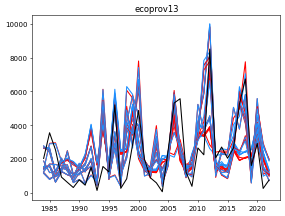

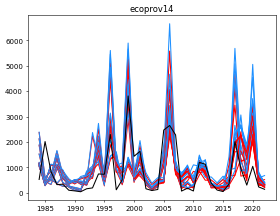

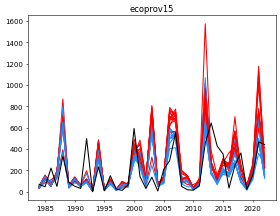

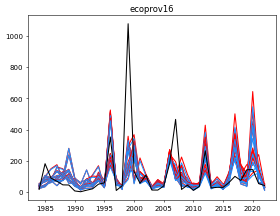

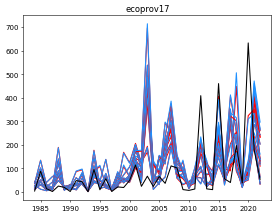

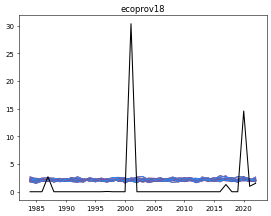

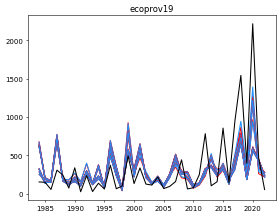

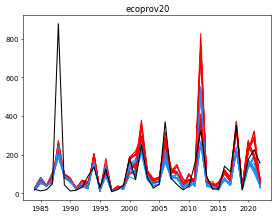

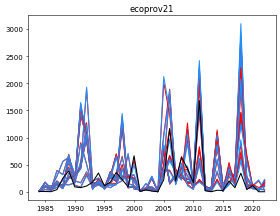

In [ ]:
# same model for NONFOREST area
print('NONFOREST')
landname = 'non'
#modeloutputfile = model_string + 'modeloutput_burnarea_'+landname+'.txt'
#f = open(modeloutputfile, 'w') # print to this file
labels = dfframesnon['allwestUS'].columns.values # each climate variable

for iregion in np.arange(len(province_num)):
    print('+++ model for ' + dfnames[iregion] + '\t AICC \t r-value')
    BACVtmpstorage = np.zeros(len(wuminon.iloc[:,0])) # storage
    BACVtmpstorageDT = np.zeros(len(wuminon.iloc[:,0])) # storage for dt scenario
    
    # PLOT
    fig, ax = plt.subplots(dpi=50)
    ax.plot(years, wuminon.iloc[:,iregion], color='k', zorder=2)
    ax.set_title(dfnames[iregion])
    
    for leavethis in groupsleaveout:
        tmpr = np.zeros(len(labels)) # storage for regression correlation
        tmpr_clim = np.zeros(len(labels)) # storage for r corr, clim vs. BA
        tmpr_climDT = np.zeros(len(labels)) # storage for r corr, climDT vs. BA_DT
        aicc = np.zeros(len(labels)) # storage for aicc values for each set of reg fit
        tmpaicc = [] # storage for aicc values for each model
        tmpi = [] # empty list of indices for variables
    
        # get observed ecoregion burned area, but set min value
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wuminon.iloc[:,iregion])).filled(0))

        # leave one out!
        tmpfire = np.delete(tmpfire, leavethis)
        
        tmpfiremin = tmpfire[tmpfire!=0].min()
        tmpfire[tmpfire==0] = tmpfiremin # replace 0 with minimum nonzero value
        tmpfireDT = annualDetrend(tmpfire)
        
        tmpfiresum = wuminon.iloc[:,iregion].sum()
        
        for i, label in enumerate(labels):
            tmpclim = np.asarray(dfframesnon[dfnames[iregion]][label].values)
            # leave one out! 
            tmpclim = (np.delete(tmpclim, leavethis)).reshape(-1,1)
            tmpclimDT = annualDetrend(tmpclim.flatten())
            reg = LinearRegression() # least squares
            reg.fit(tmpclim, tmpfire)
            tmppredict = reg.predict(tmpclim)
            tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
            # calculate AICc for each
            nyears = len(tmpfire)
            npredictors = reg.n_features_in_
            aicc[i] = getAICc(tmpr[i], nyears, npredictors)
            # compare signs
            tmpr_clim = pearsonr(tmpclim.flatten(), tmpfire)
            tmpr_climDT = pearsonr(tmpclimDT, tmpfireDT)
            # check if the correlation is right sign physically
            tmplabeljustvar = label.split(' ')[0]
            tmplabeljustyr = label.split(' ')[1]
            tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
            # wrong signs
            tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
            tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
            if tmpwrong3 or tmpwrong4:
                aicc[i] = 99 # overwrite the AICc value
                
            # check if they are the same sign
            tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
            tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
            #if tmpsign==False:
            #    print('\tSIGN CHANGE ' + label + '\t'+
            #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
            #if tmppvalue==False:
            #    print('\tDT INSIGNIFICANT ' + label + '\t'+
            #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
            if (tmpsign==False) or (tmppvalue==False):
                aicc[i] = 99 # overwrite the AICc value
                #print('\tOverwrite AICc')
        # get minimum
        [iminaicc, minaicc] = np.argmin(aicc), np.min(aicc)
        tmpi.append(iminaicc) # add min to list of variables
        tmpaicc.append(minaicc) # add aicc value to list
    
        if (minaicc>0) or (tmpfiresum<minfiresum): # we overwrite the model and exit
            # need all write/output requirements because we're EXITING THIS leavethis in GROUPSLEAVEOUT!!!
            tmpclim = np.asarray(dfframesnon[dfnames[iregion]].iloc[:,tmpi].values)
            # leave one out!
            tmpclim = np.delete(tmpclim, leavethis).reshape(-1,1)
            reg = LinearRegression()
            reg.fit(tmpclim, tmpfire)
            reg.coef_ = np.asarray([0]) # change coeff to 0
            reg.intercept_ = np.asarray(tmpfire.mean())
            #f_vars.write(labels[iminaicc] + '\n' + str(tmpclim.flatten()) + '\n') # write variable data to file
            #print('\tAICc POSITIVE--EXIT')
            #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
            #      str(np.round(tmpr[iminaicc], decimals=3)))
            
            tmpcoef = reg.coef_
            tmpintercept = reg.intercept_
 
            # re-predict with full timeseries
            tmpclim = np.asarray(dfframesnon[dfnames[iregion]][label].values).reshape(-1,1)
            tmppred = reg.predict(tmpclim)
    
            dfmodelnon[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list0.
            
            # (9/8/2024) ADD ERROR ENSEMBLE
            # create random error matrix (with replacement, index left in)
            istop = 0
            iyears = np.arange(0,len(years)) # index of each year
            errormatrix = np.empty((0,len(years)))
            while istop < (nensemble):
                # randomly select errors and construct a timeseries (years x ensembles)
                tmprandom = np.array([np.random.choice(iyears) for i in range(len(iyears))])
                tmprandom = tmprandom.reshape(1, -1)
                errormatrix = np.concatenate([errormatrix, 
                                              tmprandom], axis=0)
                istop+=1
            # error time series (BA obs - model)
            tmpBA_error_log10 = BA_obsnon.iloc[:,iregion] - tmppred
            # get nensemble of random errors
            tmpBA_randomerror = np.empty((0,len(years)))
            for j in np.arange(0,nensemble):
                tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
                tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                                   tmpcolerror], axis=0)
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred = np.log10(tmpBA_mod_plus_error1)

            # (11/17/2025) Predict climate under detrended gSST scenario
            # fits it to the model trained on observed climate
            tmpX = dfsstclimnon[dfnames[iregion]].iloc[:,tmpi] 
            tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
            # add error ensemble
            # add BA_model to the errors, then unlog, create pd dataframe
            tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
            tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
            # RULE: set negative values to zero
            tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
            # take mean mod+error of all n columns
            tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
            # make this the new tmppred (the BA_mod) (convert back to log10)
            tmppred_DT = np.log10(tmpBA_mod_plus_error1)
            
    
            # save the predicted values (only the out-of-sample ones
            BACVtmpstorage[leavethis] = tmppred[leavethis]
            BACVtmpstorageDT[leavethis] = tmppred_DT[leavethis]

            # PLOT
            ax.plot(years, 10**(tmppred), color='red', zorder=0)
            ax.plot(years, 10**(tmppred_DT), color='dodgerblue', zorder=0)
            continue # leave this loop
        
        # calculate residuals from one-variable model
        # and leave one out!
        tmpclim = dfframesnon[dfnames[iregion]].iloc[:,tmpi].drop(leavethis)
        reg = LinearRegression()
        reg.fit(tmpclim, tmpfire)
        tmppredictprior = reg.predict(tmpclim)
    
        #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
        #          str(np.round(tmpr[iminaicc], decimals=3)))
        
        # define starting difference in aicc to get the for-loop to start
        diffaicc = -3
        # multiple regression using remaining predictor, until aicc is not improved
        while diffaicc < -2:
            # add another variable to get new model
            # calculate residuals
            tmpresids = np.log10((10**tmpfire)/(10**tmppredictprior))
            # go through each variable and get the correlation
            tmpr = np.zeros(len(labels)) # storage for regression correlation
            for i, label in enumerate(labels):
                tmpclimnew = np.asarray(dfframesnon[dfnames[iregion]][label])
                # leave one out! 
                tmpclimnew = np.delete(tmpclimnew, leavethis).reshape(-1,1)
                tmpclimprior = dfframesnon[dfnames[iregion]].iloc[:,tmpi].drop(leavethis)
                tmpX = np.hstack((tmpclimprior, tmpclimnew)) # all X variables
                tmpclimnewDT = annualDetrend(tmpclimnew.flatten())
                tmpresidsDT = annualDetrend(tmpresids)
                reg = LinearRegression() # least squares
                reg.fit(tmpX, tmpfire)
                tmppredict = reg.predict(tmpX)
                tmpr[i] = pearsonr(tmpfire.flatten(), tmppredict.flatten()).statistic
                # calculate AICc for each
                nyears = len(tmpfire)
                npredictors = reg.n_features_in_
                aicc[i] = getAICc(tmpr[i], nyears, npredictors)
                # compare signs
                tmpr_clim = pearsonr(tmpclimnew.flatten(), tmpresids)
                tmpr_climDT = pearsonr(tmpclimnewDT, tmpresidsDT)
                # check if correlation is the right sign physically
                tmplabeljustvar = label.split(' ')[0]
                tmplabeljustyr = label.split(' ')[1]
                tmpnameyrlabel = tmplabeljustvar + ' ' + tmplabeljustyr
                # wrong signs
                tmpwrong3 = (tmpr_clim.statistic < 0) & (tmplabeljustvar in clim_poscorrboth)
                tmpwrong4 = (tmpnameyrlabel in clim_correxclude)
                if tmpwrong3 or tmpwrong4:
                    aicc[i] = 99 # overwrite the AICc value
                # check if they are the same sign
                tmpsign = ((tmpr_clim.statistic > 0) == (tmpr_climDT.statistic > 0))
                tmppvalue = (tmpr_climDT.pvalue < 0.1) # check significance
                #if tmpsign==False:
                #    print('\tSIGN CHANGE ' + label + '\t'+
                #              'r={:.5f} \t r={:.5f}'.format(tmpr_clim.statistic, tmpr_climDT.statistic))
                #if tmppvalue==False:
                #    print('\tDT INSIGNIFICANT ' + label + '\t'+
                #              'p={:.5f} \t p={:.5f}'.format(tmpr_clim.pvalue, tmpr_climDT.pvalue))
                if (tmpsign==False) or (tmppvalue==False):
                    aicc[i] = 99 # overwrite the AICc value
                    #print('\tOverwrite AICc')
    
            # get minimum
            [iminaicc, minaicc] = np.nanargmin(aicc), np.nanmin(aicc)
            # check aicc value to previous value
            diffaicc = minaicc - tmpaicc[-1]
            # check if diff aicc is small enough before continuing
            #print('diffaicc = {:} - {:}'.format(minaicc, tmpaicc[-1]))
            if (diffaicc >= -2):
                #print('difference is too big, EXIT ' + str(diffaicc)) 
                continue # exit loop
            else:
                # continue this part if aicc < -2
                tmpi.append(iminaicc) # add min to list of variables
                tmpaicc.append(minaicc) # add aicc value to list
                #print(labels[iminaicc]+ '\t' + str(np.round(minaicc, decimals=3))+ '\t' + 
                #          str(np.round(tmpr[iminaicc], decimals=3)))
    
                # calculate residuals from this current model
                tmpX = dfframesnon[dfnames[iregion]].iloc[:,tmpi].drop(leavethis) # all the variables
                reg = LinearRegression()
                reg.fit(tmpX, tmpfire) # fit the final model
                tmppredictprior = reg.predict(tmpX)
    
        # fit the final model - keep all of the timeseries in!
        tmpX = dfframesnon[dfnames[iregion]].iloc[:,tmpi]
        tmpfire = np.asarray(np.ma.masked_invalid(np.log10(wuminon.iloc[:,iregion])).filled(0))
        reg.fit(tmpX, tmpfire) # fit the final model
        tmppred = reg.predict(tmpX)

        # (9/8/2024) ADD ERROR ENSEMBLE
        # create random error matrix (with replacement, index left in)
        istop = 0
        errormatrix = np.empty((0,len(years)))
        iyears = np.arange(0,len(years)) # index of each year
        while istop < (nensemble):
            # randomly select errors and construct a timeseries (years x ensembles)
            tmprandom = np.array([np.random.choice(iyears) for i in range(len(iyears))])
            tmprandom = tmprandom.reshape(1, -1)
            errormatrix = np.concatenate([errormatrix, 
                                          tmprandom], axis=0)
            istop+=1
        # error time series (BA obs - model)
        tmpBA_error_log10 = BA_obsnon.iloc[:,iregion] - tmppred
        # get nensemble of random errors
        tmpBA_randomerror = np.empty((0,len(years)))
        for j in np.arange(0,nensemble):
            tmpcolerror = tmpBA_error_log10.iloc[errormatrix[j]].values.reshape(1, -1)
            tmpBA_randomerror = np.concatenate([tmpBA_randomerror, 
                                               tmpcolerror], axis=0)
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred = np.log10(tmpBA_mod_plus_error1)

        # (11/17/2025) Predict climate under detrended gSST scenario
        # fits it to the model trained on observed climate
        tmpX = dfsstclimnon[dfnames[iregion]].iloc[:,tmpi] 
        tmppred_DT = reg.predict(tmpX) # predicted BA, detrended scenario
        # add error ensemble
        # add BA_model to the errors, then unlog, create pd dataframe
        tmpBA_mod_plus_error = 10**(tmppred_DT[:, np.newaxis] + tmpBA_randomerror.T)
        tmpBA_mod_plus_error = pd.DataFrame(tmpBA_mod_plus_error, index=years)
        # RULE: set negative values to zero
        tmpBA_mod_plus_error[tmpBA_mod_plus_error<0] = 0
        # take mean mod+error of all n columns
        tmpBA_mod_plus_error1 = tmpBA_mod_plus_error.mean(axis=1).values
        # make this the new tmppred (the BA_mod) (convert back to log10)
        tmppred_DT = np.log10(tmpBA_mod_plus_error1)
        

        # PLOT
        ax.plot(years, 10**(tmppred), color='red', zorder=0)
        ax.plot(years, 10**(tmppred_DT), color='dodgerblue', zorder=0)
        
        # save the predicted values (only the out-of-sample ones
        BACVtmpstorage[leavethis] = tmppred[leavethis]
        BACVtmpstorageDT[leavethis] = tmppred_DT[leavethis]
        
        dfmodelnon[dfnames[iregion]] = [labels[i] for i in tmpi] # add this ecoregion's values to list0.
    # store it for the ecoprovince
    BACVprednon[dfnames[iregion]] = BACVtmpstorage
    BACVsstnon[dfnames[iregion]] = BACVtmpstorageDT

In [ ]:
# export burned area
# forest
BACVpredfor_arr = np.array(list(BACVpredfor.values())).T
BACVpredfor_df = pd.DataFrame(BACVpredfor_arr, columns=dfnames, index=years)
filename = predict_string + 'BurnArea_'+'crossvalid_for'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
BACVpredfor_df.to_csv(filename)
# nonforest
BACVprednon_arr = np.array(list(BACVprednon.values())).T
BACVprednon_df = pd.DataFrame(BACVprednon_arr, columns=dfnames, index=years)
filename = predict_string + 'BurnArea_'+'crossvalid_non'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
BACVprednon_df.to_csv(filename)

# export burned area, DETRENDED, counterfactual scenario (11/17/2025)
# forest
BACVsstfor_arr = np.array(list(BACVsstfor.values())).T
BACVsstfor_df = pd.DataFrame(BACVsstfor_arr, columns=dfnames, index=years)
filename = predict_string + 'BurnArea_'+'crossvalid_for'+'_DeTrend_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
BACVsstfor_df.to_csv(filename)
# nonforest
BACVsstnon_arr = np.array(list(BACVsstnon.values())).T
BACVsstnon_df = pd.DataFrame(BACVsstnon_arr, columns=dfnames, index=years)
filename = predict_string + 'BurnArea_'+'crossvalid_non'+'_DeTrend_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
BACVsstnon_df.to_csv(filename)

# Supporting Info figures

(3/4/2024) Figures for the science advances supporting info on cross-validation.

Can run this separately from the cross-validation calculation above, just remember to run the imports and manually-inputted stuff in the top few notebook cells.

In [ ]:
# printing significance
def addSigMarker(pvalue):
    """
    Add an asterisk for values that are significant.
    p<0.05, add *
    p<0.01, add **
    otherwise add an empty space
    """
    if pvalue<0.01:
        adddot = '**' # significance marker
    elif pvalue<0.05:
        adddot = '*'# add significance marker
    else:
        adddot = ' ' # no significance
    return adddot

In [ ]:
# import fire data, both modis and wumi databases
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

In [ ]:
# import the exported cross-validation
filename = predict_string + 'BurnArea_'

BACVpredfor = pd.read_csv(filename+'crossvalid_for'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BACVprednon = pd.read_csv(filename+'crossvalid_non'+'_'+climindname+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

In [ ]:
# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

filename = predict_string + 'BurnArea_'

# predicted burned area from observed climate
BAclimpredfor = pd.read_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon = pd.read_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

In [ ]:
 # color palette (to match the same main fig colors)
colorobs = '#E2725B' # a warm red to denote warming
colorCross = '#4F0798' # funky dark purple

# set fonts
plt.rcParams.update({'font.size': 15})
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Arial'

In [ ]:
# forest figure of the r-values for each ecoprovince

years = np.arange(firstyear, finalyear+1)
fig, ax = plt.subplots(6,3, figsize=(13,13))
figrow = np.arange(0,6)
figcol = np.arange(0,3)
r_forfull = [] # store Pearson correlation
r_forCV = []

i = 0
j = 0
for thisrow in figrow:
    for thiscol in figcol:
        if i>=(len(dfnames)):
            break
        if (dfnames[i]=='allwestUS') or (dfnames[i]=='ecoprov3') or (dfnames[i]=='ecoprov6') or (dfnames[i]=='ecoprov18'):
            print(str(i)+' will be skipped')
            i+=1
        thisname = dfnames[i]
        tmptoplot = BACVpredfor[thisname]
        tmptoplot2 = (BAclimpredfor.loc[:,thisname])
        tmpobs = wumifor.iloc[:,i]
        tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
        tmpr, tmpp = pearsonr(tmpobslog, tmptoplot)
        tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2)
        ax[thisrow,thiscol].plot(years, tmpobs, ':', color='k', label='obs')
        ax[thisrow,thiscol].plot(years, 10**(tmptoplot2), 
                                 color=colorobs, label='fullmodel',
                                linewidth=2)
        ax[thisrow,thiscol].plot(years, 10**(tmptoplot), 
                                 color=colorCross, label='OOS pred',
                                linewidth=1.5)
        tmppformat = addSigMarker(tmpp)
        tmppformat2 = addSigMarker(tmpp2)
        ax[thisrow,thiscol].set_title(prov_label_names[j],loc='left',fontsize=14)
        
        r_forCV.append(tmpr)
        r_forfull.append(tmpr2)
        
        # set height
        tmpmax_val = np.array([10**tmptoplot2]+[tmpobs]).max()
        tmprounded_max = np.ceil(tmpmax_val / 5) * 5 
        current_min = ax[thisrow,thiscol].get_ylim()[0]
        #ax[thisrow,thiscol].set_xlim([1978,finalyear+5])
        ax[thisrow,thiscol].set_ylim([current_min,tmprounded_max*1.3])

        # no model produced for these ecoprovinces
        if j in [1-1,5-1,17-1]:
            ax[thisrow,thiscol].annotate('No model produced',(0.04,0.80),
                                         ha='left', c=colorobs, xycoords='axes fraction',
                                         fontsize=14)
        # if model exists, print r-values
        else:
            ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), 
                    (0.04,0.80), c=colorobs, xycoords='axes fraction' )
            ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), 
                    (0.04,0.65), c=colorCross, xycoords='axes fraction' )
        
        i+=1
        j+=1
fig.supylabel('Area burned (km$^2$)')
fig.supxlabel('Year')
fig.suptitle('Observed, Fully-Calibrated, and Cross-Validated Model BA, (Forest), '
             +str(firstyear)+'-'+str(finalyear))
fig.delaxes(ax[5,2])
fig.legend(['Observed', 'Final model', 'Cross-validated model'],
           frameon=False, bbox_to_anchor=(0.88,0.20))

k=0
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
# add figure labels
for thisrow in figrow:
    for thiscol in figcol:
        thisfiglabel = figlabels[k]
        ax[thisrow,thiscol].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.05), 
                                     c='k', xycoords='axes fraction')
        k+=1
        
plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.1, right=0.92, top=0.9, bottom=0.1)

plt.savefig(figfolder + 'Suppl_CrossValid_Ecoprov_Forest.png', bbox_inches="tight")

In [ ]:
# nonforest figure of the r-values for each ecoprovince

years = np.arange(firstyear, finalyear+1)
fig, ax = plt.subplots(6,3, figsize=(13,13))
figrow = np.arange(0,6)
figcol = np.arange(0,3)
r_nonfull = [] # store Pearson correlation
r_nonCV = []

i = 0
j = 0
for thisrow in figrow:
    for thiscol in figcol:
        if i>=(len(dfnames)):
            break
        if (dfnames[i]=='allwestUS') or (dfnames[i]=='ecoprov3') or (dfnames[i]=='ecoprov6') or (dfnames[i]=='ecoprov18'):
            i+=1
        thisname = dfnames[i]
        tmptoplot = BACVprednon[thisname]
        tmptoplot2 = (BAclimprednon.loc[:,thisname])
        tmpobs = wuminon.iloc[:,i]
        tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
        tmpr, tmpp = pearsonr(tmpobslog, tmptoplot)
        tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2)
        ax[thisrow,thiscol].plot(years, tmpobs,':', color='k', label='obs')
        ax[thisrow,thiscol].plot(years, 10**(tmptoplot2), 
                                 color=colorobs, label='fullmodel',
                                linewidth=2)
        ax[thisrow,thiscol].plot(years, 10**(tmptoplot), 
                                 color=colorCross, label='OOS pred',
                                linewidth=1.5)
        ax[thisrow,thiscol].set_title(prov_label_names[j],loc='left',fontsize=14)
        
        tmppformat = addSigMarker(tmpp)
        tmppformat2 = addSigMarker(tmpp2)
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), (0.04,0.80), 
                c=colorobs, xycoords='axes fraction' )
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), (0.04,0.65), 
                c=colorCross, xycoords='axes fraction' )
        r_nonCV.append(tmpr)
        r_nonfull.append(tmpr2)
        # set height
        tmpmax_val = np.array([10**tmptoplot2]+[tmpobs]).max()
        tmprounded_max = np.ceil(tmpmax_val / 5) * 5 
        current_min = ax[thisrow,thiscol].get_ylim()[0]
        #ax[thisrow,thiscol].set_xlim([1978,finalyear+5])
        ax[thisrow,thiscol].set_ylim([current_min,tmprounded_max*1.3])

        
        i+=1
        j+=1
fig.supylabel('Area burned (km$^2$)')
fig.supxlabel('Year')
fig.suptitle('Observed, Fully-Calibrated, and Cross-Validated Model BA, (Non-Forest), '
             +str(firstyear)+'-'+str(finalyear))
fig.delaxes(ax[5,2])
fig.legend(['Observed','Final model', 'Cross-validated model'],
           frameon=False, bbox_to_anchor=(0.88,0.20))

k=0
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
# add figure labels
for thisrow in figrow:
    for thiscol in figcol:
        thisfiglabel = figlabels[k]
        ax[thisrow,thiscol].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.05), c='k', xycoords='axes fraction')
        k+=1

plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.1, right=0.92, top=0.9, bottom=0.1)

        
fig.savefig(figfolder + 'Suppl_CrossValid_Ecoprov_NonForest.png', bbox_inches="tight")

In [ ]:
# ALL=forest+nonforest figure of the r-values for each ecoprovince

years = np.arange(firstyear, finalyear+1)
fig, ax = plt.subplots(6,3, figsize=(13,13))
figrow = np.arange(0,6)
figcol = np.arange(0,3)
r_allfull = [] # store Pearson correlation
r_allCV = []

i = 0
j = 0
for thisrow in figrow:
    for thiscol in figcol:
        if i>=(len(dfnames)):
            break
        if (dfnames[i]=='allwestUS') or (dfnames[i]=='ecoprov3') or (dfnames[i]=='ecoprov6') or (dfnames[i]=='ecoprov18'):
            i+=1
        thisname = dfnames[i]
        tmptoplot = (10**BACVprednon[thisname])+(10**BACVpredfor[thisname])
        tmptoplot2 = (10**(BAclimprednon.loc[:,thisname]))+(10**BAclimpredfor.loc[:,thisname])
        tmptoplotlog = np.ma.masked_invalid(np.log10(tmptoplot)).filled(0)
        tmptoplot2log = np.ma.masked_invalid(np.log10(tmptoplot2)).filled(0)
        tmpobs = wuminon.iloc[:,i]+wumifor.iloc[:,i]
        tmpobslog = np.ma.masked_invalid(np.log10(tmpobs)).filled(0)
        tmpr, tmpp = pearsonr(tmpobslog, tmptoplotlog)
        tmpr2, tmpp2 = pearsonr(tmpobslog, tmptoplot2log)
        ax[thisrow,thiscol].plot(years, tmpobs,':', color='k', label='obs')
        ax[thisrow,thiscol].plot(years, tmptoplot2, 
                                 color=colorobs, label='fullmodel',
                                linewidth=2)
        ax[thisrow,thiscol].plot(years, tmptoplot, 
                                 color=colorCross, label='OOS pred',
                                linewidth=1.5)
        ax[thisrow,thiscol].set_title(prov_label_names[j],loc='left',fontsize=14)
        
        tmppformat = addSigMarker(tmpp)
        tmppformat2 = addSigMarker(tmpp2)
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), (0.04,0.80), 
                c=colorobs, xycoords='axes fraction' )
        ax[thisrow,thiscol].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), (0.04,0.65), 
                c=colorCross, xycoords='axes fraction' )
        r_allCV.append(tmpr)
        r_allfull.append(tmpr2)

        # set height
        tmpmax_val = np.array([10**tmptoplot2log]+[tmpobs]).max()
        tmprounded_max = np.ceil(tmpmax_val / 5) * 5 
        current_min = ax[thisrow,thiscol].get_ylim()[0]
        #ax[thisrow,thiscol].set_xlim([1978,finalyear+5])
        ax[thisrow,thiscol].set_ylim([current_min,tmprounded_max*1.3])
        i+=1
        j+=1
fig.supylabel('Area burned (km$^2$)')
fig.supxlabel('Year')
fig.suptitle('Observed, Fully-Calibrated, and Cross-Validated Model BA, (Forest+Non-Forest), '
             +str(firstyear)+'-'+str(finalyear))
fig.delaxes(ax[5,2])
fig.legend(['Observed','Final model','Cross-validated model'],
           frameon=False, bbox_to_anchor=(0.88,0.20))

k=0
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
# add figure labels
for thisrow in figrow:
    for thiscol in figcol:
        thisfiglabel = figlabels[k]
        ax[thisrow,thiscol].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.08), c='k', xycoords='axes fraction')
        k+=1

plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.1, right=0.92, top=0.9, bottom=0.1)

        
fig.savefig(figfolder + 'Suppl_CrossValid_Ecoprov-Forest+NonForestSum.png', bbox_inches="tight")

## note CUSTOM: remove the irrelevant ecoprovinces

manual removal of the ecoprovinces when doing the whole ecoprovince sum

In [ ]:
# CUSTOM REMOVE SOME
# skip analysis for these ecoprovinces for low fire occurrence
# create filter for westUS + ecoprovs
df_filter = np.ones(len(dfnames))
dfnames_filter = ['ecoprov3', 'ecoprov6', 'ecoprov18']
for thisname in dfnames_filter:
    df_filter[dfnames.index(thisname)] = 0 # filter out this ecoregion
# filter arrays
dfnames = list(compress(dfnames, df_filter))

# create filter for ecoprovs
df_filternum = np.ones(len(province_num))
dfnum_filter = np.array([3,6,18])
for thisnum in dfnum_filter:
    df_filternum[province_num==thisnum] = 0 # filter out this ecoregion
# filter arrays
province_names = list(compress(province_names, df_filternum[1:]))
prov_abbr_names = list(compress(prov_abbr_names, df_filternum[1:]))
province_num = np.array(list(compress(province_num, df_filternum)))
dfnum = province_num[1:]

In [ ]:
# Add up burned area from every year to get sum of western US

# first remove irrelevant ecoprovinces
dfnum_list = [str(x) for x in dfnum]
#wumifor = wumifor.loc[:,dfnum_list]
#wumifor['0'] = wumifor.loc[:,dfnum_list].sum(axis=1)

# start with dataframes
BACVpredfor_df = pd.DataFrame(BACVpredfor)
BACVprednon_df = pd.DataFrame(BACVprednon)

BACVpredfor_df = BACVpredfor_df.loc[:,dfnames]
BACVprednon_df = BACVprednon_df.loc[:,dfnames]
BAclimpredfor = BAclimpredfor.loc[:,dfnames]
BAclimprednon = BAclimprednon.loc[:,dfnames]

# replace the value in allwestUS with the sum of each ecoprovince
BACVpredfor_df['allwestUS'] = np.log10((10**BACVpredfor_df.iloc[:,1:]).sum(axis=1))
BACVprednon_df['allwestUS'] = np.log10((10**BACVprednon_df.iloc[:,1:]).sum(axis=1))

In [ ]:
# final years
xyears = np.arange(firstyear,finalyear+1,1)

sumswumi = [wumifor.loc[:,'0'], wuminon.loc[:,'0'], wumi.loc[:,'0']]
BACVpredall = 10**BACVpredfor_df['allwestUS']+10**BACVprednon_df['allwestUS']
sumsBA = [10**BACVpredfor_df['allwestUS'], 10**BACVprednon_df['allwestUS'], BACVpredall]
BAclimpredall = 10**(BAclimpredfor.loc[:,'allwestUS'])+10**(BAclimprednon.loc[:,'allwestUS'])
sumsBA2 = [10**BAclimpredfor.loc[:,'allwestUS'], 10**BAclimprednon.loc[:,'allwestUS'], BAclimpredall]

# make plot
fig, ax = plt.subplots(3,1, figsize=(5,8), dpi=200)

fig.suptitle('Burned Area, Observed, Fully-calibrated model,\n and Cross-validated model, '
             +str(firstyear)+'-'+str(finalyear))
for i in np.arange(0,3):
    ax[i].plot(sumswumi[i], ':',label='Observed', c='k', linewidth=1)
    ax[i].plot(xyears, sumsBA2[i], label='Full model', c=colorobs,
              linewidth=2)
    ax[i].plot(xyears, sumsBA[i], label='From cross-validated model', c=colorCross,
              linewidth=1.5)
    ax[i].set_ylabel('Area burned (km$^2$)')
    tmpr, tmpp = pearsonr(np.log10(sumswumi[i]), np.log10(sumsBA[i]))
    tmpr2, tmpp2 = pearsonr(np.log10(sumswumi[i]), np.log10(sumsBA2[i]))

    # add r-value to plot
    tmppformat = addSigMarker(tmpp)
    tmppformat2 = addSigMarker(tmpp2)
    ax[i].annotate("$r$"+"= {:.2f}{:}".format(tmpr2, tmppformat2), (0.03,0.75), 
                c=colorobs, xycoords='axes fraction' )
    ax[i].annotate("$r$"+"= {:.2f}{:}".format(tmpr, tmppformat), (0.03,0.60), 
                c=colorCross, xycoords='axes fraction' )
fig.legend(['Observed','Final fully-calibrated model',
           '13-fold cross validated model'], frameon=False,
           bbox_to_anchor=(0.78,0.88), fontsize='x-small',)
ax[2].set_xlabel('Years')
ax[2].set_title('Forest+Nonforest', loc='left')
ax[0].set_title('Forest', loc='left')
ax[1].set_title('Non-forest', loc='left')
#ax[2].annotate('All',(0.06,0.85), c='#000', xycoords='axes fraction' )
#ax[0].annotate('Forest',(0.06,0.85), c='#000', xycoords='axes fraction' )
#ax[1].annotate('Non-forest',(0.06,0.85), c='#000', xycoords='axes fraction' )

# set height
current_min, current_max = ax[0].get_ylim()
ax[0].set_ylim([current_min,current_max*1.3])

k=0
figlabels = [chr(i) for i in range(65, 65 + 3)]
# add figure labels
for i in np.arange(3):
    thisfiglabel = figlabels[k]
    ax[i].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.1,1.05), c='k', xycoords='axes fraction')
    k+=1
fig.patch.set_alpha(0)
plt.subplots_adjust(wspace=0.22, hspace=0.5, left=0.08, right=0.92, top=0.87, bottom=0.1)

        
fig.savefig(figfolder + 'Suppl_CrossValid_ModelAllSums.png', bbox_inches="tight")

# maps of correlation values

(6/25/2024)

**Comment from Park on draft v2 of paper, May 14, 2024:** I also would like to suggest more SI figs. This section would be aided by some correlation maps. I suggest one figure with a pair of maps showing 
1. fully-calibrated correlation and cross-validated correlation by ecoprovince (below), and
2. then another pair of maps that is the same but breaks out forest and non-forest. (below)
3. I also suggest another set of regional time series plots that represents total area burned (forest + non-forest). (done, above)

In [ ]:
# import ecoprovinces first, then use them to plot
# mapping
import geopandas as gpd
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import Colorbar
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, LAND
from shapely.geometry import Polygon
from shapely.geometry import JOIN_STYLE
from shapely.ops import unary_union

In [ ]:
# translate years into dates
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

#ecoreg_string = directory + '12km\\landcover\\Ecoregions_EPA\\bailey_ecoprovince.nc'
ecoreg_string = directory + '12km//landcover//Ecoregions_EPA//bailey_ecoprovince.nc'
ecoreg = xr.open_dataset(ecoreg_string, engine='netcdf4')
print(ecoreg.bailey_ecoprovince.province.legend)
ecoreg = ecoreg.bailey_ecoprovince

# import western US study area
#westUS_string = directory + '12km\\study_area\\westUS.nc'
westUS_string = directory + '12km//study_area//westUS.nc'
westUS = xr.open_dataset(westUS_string, engine='netcdf4')
westUS = westUS.westUS

# add in entire western US
#ecoreg = xr.concat([westUS, ecoreg.bailey_ecoprovince], dim='province')
# remove the ecoregion that does not overlap with the western US
ecoreg = ecoreg.sel(province=dfnum)
ecoreg = westUS*ecoreg # crop to western US only

## for Ecoprovince map

* `Becoprov` to plot shapefiles of Bailey's Ecoprovinces on a map so they can be colored according to data.
    * The CRS used is defined within the shapefile, so **no need to call `transform` when plotting**
* `ecoreg` to plot xarray-based gridded data of Bailey's ecoprovinces on a figure.
    * Use CRS `ccrs.PlateCarree()` when plotting

In [ ]:
# import Bailey's Ecoregions
#Bailey_string = '1km\\landcover\\ecoregions\\shapefiles\\bailey\\eco-us-shp-GCS\\eco-us-shp-GCS.shp'
Bailey_string = '1km//landcover//ecoregions//shapefiles//bailey//eco-us-shp-GCS//eco-us-shp-GCS.shp'
Becoreg = gpd.read_file(directory + Bailey_string)

# projection info from file
Bailey_crs = Becoreg.crs
# projection info from website
#EPA_crs2 = ccrs.LambertAzimuthalEqualArea(central_longitude=-100, central_latitude=45, 
#                                         false_easting=0.0, false_northing=0.0, globe=None)

# get shapefile of just western US from US Census Bureau
# for some reason it includes Hawaii and Alaska
#Census_string = directory + 'Census Bureau\\Cartographic Boundary Files_Regions\\cb_2018_us_region_500k.shp'
Census_string = 'Census Bureau//Cartographic Boundary Files_Regions//cb_2018_us_region_500k.shp'
wUSregion = gpd.read_file(directory + Census_string)
wUSregion = wUSregion[wUSregion.NAME=='West']
# remove HI and AK
extentpoly = Polygon([(-130,30), (-130,50), (-100,50),(-100,30)])
poly_gdf = gpd.GeoDataFrame(geometry=[extentpoly], crs=ccrs.PlateCarree())
wUSregion = wUSregion.clip(extentpoly)

wUSregion = wUSregion.to_crs(Bailey_crs) # transform projection

# clip the ecoregions to just western US
Becoreg = gpd.clip(Becoreg, wUSregion)
# sort to the same order as data
Becoreg = Becoreg.set_index('PROVINCE')
Becoreg = Becoreg.loc[province_names]

# iterate through ecoregions and merge into ecoprovinces
# group the data by ecoregion
Becoprov = gpd.GeoDataFrame(columns=['PROVINCE','NUMBER','geometry'], geometry='geometry')
gbecoreg = Becoreg.groupby('PROVINCE')
i = 0 # start counter
eps = 0.001 # define buffer
# iterate through each province and MERGE the ecoregions
for thisname, thisgroup in gbecoreg:
    thisgeometry = thisgroup.geometry.to_crs('epsg:5070') # set CRS with m as unit
    thisgeometry = thisgeometry.buffer(eps, 1, join_style=JOIN_STYLE.mitre) # add buffer
    thisgeometry = unary_union(thisgeometry).buffer(-eps, 1, join_style=JOIN_STYLE.mitre) # merge, then remove buffer
    thisgeometry = gpd.GeoSeries(thisgeometry).set_crs('epsg:5070').to_crs('epsg:4326') # set CRS with degrees
    #thisgeometry = gpd.GeoSeries(unary_union(thisgroup.geometry))
    thisprovince = gpd.GeoDataFrame(data={'PROVINCE': thisname, 
                                          'NUMBER': province_num[i], 
                                          'geometry': thisgeometry}, geometry='geometry')
    # append to create ecoprovince geodataframe
    Becoprov = gpd.GeoDataFrame(pd.concat([Becoprov, thisprovince], ignore_index=True))
    i+=1

# Becoprov is now a geodataframe I can use, with SHAPEFILES of provinces.

## import forest and nonforest area
* `westUS` is xarray-based gridded data of the western US region.
* `forest` is xarray-based forest gridded data, within western US.
* `nonforest` is xarray-based nonforest gridded data within western US.
* `ecoreg` is xarray-based ecoprovinces
* `ecoregfor` is xarray-based ecoprovinces, forest area only
* `ecoregnon` is xarray-based ecoprovinces, nonforest area only

In [ ]:
# import western US study area
#westUS_string = directory + '12km\\study_area\\westUS.nc'
westUS_string = directory + '12km//study_area//westUS.nc'
westUS = xr.open_dataset(westUS_string, engine='netcdf4')
westUS = westUS.westUS

# import forest
#forest_string = directory + '12km\\landcover\\US_ForestType_Ruefenacht\\forest_type_frac.nc'
forest_string = directory + '12km//landcover//US_ForestType_Ruefenacht//forest_type_frac.nc'
forest = xr.open_dataset(forest_string, engine='netcdf4')
forest = forest.forest_type_frac.sum(dim='ftype') # sum over all forest types

# create forest and nonforest area 
forest = westUS*forest
nonforest = westUS*(1-forest)
# add province as dimension to the westUS, to combine with ecoregions
westUS = westUS.expand_dims({'province':[0]})

In [ ]:
# divide forest and nonforest into ecoprovinces

ecoregfor = [] # storage
ecoregnon = []

# get forest and nonforest pixels only where greater than .5
for thisregnum in province_num[1:]:
    tmpfor = (forest.where(forest>.50))*ecoreg.sel(province=thisregnum)
    tmpnon = (nonforest.where(nonforest>.50))*ecoreg.sel(province=thisregnum)
    ecoregfor.append(tmpfor.to_numpy())
    ecoregnon.append(tmpnon.to_numpy())

# create xarray out of the data
ecoregfor = xr.DataArray(ecoregfor, coords={'province':ecoreg.province,
                                'Y':forest.Y, 'X':forest.X})
ecoregnon = xr.DataArray(ecoregnon, coords={'province':ecoreg.province,
                                'Y':forest.Y, 'X':forest.X})

In [ ]:
# Correlation for one to get colorbar
# gonna use r_forfull since I think the correlations are highest
# customize colorbar and color
cmapcolor = 'cet_CET_D1A'
cbarmin = -1 # set colorbar vmin and vmax
cbarmax = 1

# check out colorbar
image_corrfor = np.expand_dims(r_forfull, axis=0)
fig, ax = plt.subplots()
corrbar0 = ax.imshow(image_corrfor, cmap=cmapcolor, vmin=cbarmin, vmax=cbarmax)
ax.set_title('Correlation of observed BA with fully-calibrated model BA')

print('Forest Min', np.min(r_forfull))
print('Forest Max', np.max(r_forfull))

fig.tight_layout()

In [ ]:
# 2x2 maps of all correlations,
# fully-calibrated model vs. cross-validated model
# top row: forest+nonforest
# bottom row: pixel divided into forest or nonforest

fig = plt.figure(figsize=(8,9), dpi=200)
gs = gridspec.GridSpec(3, 4, figure=fig, height_ratios=[1,1,0.05],
                      width_ratios=[1,1,1,1])
extent = [-127,-100,30,50]

######### left side top
ax1 = fig.add_subplot(gs[0,0:2],projection=ccrs.PlateCarree())
# add map features
ax1.set_extent(extent)
ax1.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the fully-calibrated data
for thisregnum in province_num[1:]:
    xr.where((ecoreg.sel(province=thisregnum))>0,
            r_allfull[counter],np.nan).plot(
            ax=ax1, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    counter+=1

ax1.set_title('$r$(observed BA,\nfully-calibrated model BA)')
# grid
precgrid1 = ax1.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid1.top_labels = False
precgrid1.right_labels = False

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax1, zorder=2)

######### right side top
ax2 = fig.add_subplot(gs[0,2:4],projection=ccrs.PlateCarree())
# add map features
ax2.set_extent(extent)
ax2.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the cross-validated data
for thisregnum in province_num[1:]:
    xr.where((ecoreg.sel(province=thisregnum))>0,
            r_allCV[counter],np.nan).plot(
            ax=ax2, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    counter+=1
ax2.set_title('$r$(observed BA,\ncross-validated model BA')

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax2, zorder=2)

# grid
precgrid2 = ax2.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid2.top_labels = False
precgrid2.right_labels = False
precgrid2.left_labels = False

######### left side bottom
ax3 = fig.add_subplot(gs[1,0:2],projection=ccrs.PlateCarree())
# add map features
ax3.set_extent(extent)
ax3.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the fully-calibrated data
for thisregnum in dfnum:
    xr.where((ecoregfor.sel(province=thisregnum))>0,
            r_forfull[counter],np.nan).plot(
            ax=ax3, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    xr.where((ecoregnon.sel(province=thisregnum))>0,
            r_nonfull[counter],np.nan).plot(
            ax=ax3, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor,
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=0)
    counter+=1

ax3.set_title(' ')

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax3, zorder=2)
# grid
precgrid2 = ax3.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid2.top_labels = False
precgrid2.right_labels = False

######### right side bottom
ax4 = fig.add_subplot(gs[1,2:4],projection=ccrs.PlateCarree())

# add map features
ax4.set_extent(extent)
ax4.add_feature(LAND, facecolor='none', edgecolor='black')
counter = 0
# add the cross-validated data
for thisregnum in dfnum:
    xr.where((ecoregfor.sel(province=thisregnum))>0,
            r_forCV[counter],np.nan).plot(
            ax=ax4, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor, 
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=1)
    xr.where((ecoregnon.sel(province=thisregnum))>0,
            r_nonCV[counter],np.nan).plot(
            ax=ax4, vmin=cbarmin, vmax=cbarmax, cmap=cmapcolor,
            add_colorbar=False, transform=ccrs.epsg(5070), zorder=0)
    counter+=1
ax4.set_title('')

# add edgeline of each ecoregion
Becoprov.boundary.plot(linewidth=1,
               edgecolor='k', ax=ax4, zorder=2)
# grid
precgrid4 = ax4.gridlines(xlocs=(range(-130, -100, 10)), 
                  ylocs=([30, 35, 40, 45, 50]), crs=ccrs.PlateCarree(), 
                  draw_labels=True,
                  linewidth=0)
precgrid4.top_labels = False
precgrid4.right_labels = False
precgrid4.left_labels = False


########## colorbars as separate gridspec
# following: https://www.sc.eso.org/~bdias/pycoffee/codes/20160407/gridspec_demo.html
cbplot1 = plt.subplot(gs[2,1:3])
# colorbar comes from prior jupyter cell
Colorbar(mappable=corrbar0, label='r-value', cmap=cmapcolor, 
         orientation='horizontal', ax=cbplot1)

fig.tight_layout()

# figure labels
ax1.annotate('Combined forest+non-\nforest correlation',(-0.3,0.5), 
             rotation=90, c='k', ha='center', va='center', xycoords='axes fraction')
ax3.annotate('Separate forest and non-\nforest correlations',(-0.3,0.5), 
             rotation=90, c='k',ha='center', va='center', xycoords='axes fraction')
# A   C
# B   D
ax1.annotate('$\\bf{(A)}$', (-0.1,1.1), c='k', xycoords='axes fraction')
ax3.annotate('$\\bf{(B)}$', (-0.1,1.1), c='k', xycoords='axes fraction')
ax2.annotate('$\\bf{(C)}$', (-0.1,1.1), c='k', xycoords='axes fraction')
ax4.annotate('$\\bf{(D)}$', (-0.1,1.1), c='k', xycoords='axes fraction')

fig.savefig(figfolder + 'Suppl_CrossValid_MapCorrAllFor+Non.png',
           bbox_inches="tight");

In [ ]:
# print last time this model was updated
from datetime import datetime
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print('Outputting for folder = ', climindname)
print("Model last run =", dt_string)